# 01 · Your data, and how to test honestly

This notebook loads gas-sensor recordings into pandas, looks at them, and shows the single most important thing about
evaluating a gas-sensor model: **test on specimens the model has never seen**, or the score is flattery.

It uses Bosch's demo dataset from BME AI-Studio (see the note below), not recordings from your board.
To use your own data instead, point `DATA` at the `bme690` folder of the logger's SD card and use `lab.load()`.

No GPU needed here; notebooks 02 and 03 train deep models on the GPU.

> **Whose data is this?** Every result in this notebook comes from **Bosch's demo dataset**, which ships inside BME
> AI-Studio: a 2.5-hour session Bosch recorded next to a La Marzocco espresso machine, on their older **BME688**
> development kit, labelled Air, Espresso Coffee and Filter Coffee. It is *not* data from your board, and not from a
> BME690. It is used here because it is the only labelled gas-sensor data available to everyone, and because it lets
> these tools be checked against AI-Studio's own numbers.
>
> **To run this on your own recordings**, set `recs = lab.load("<your SD card>/bme690")` in the first code cell. Your
> recordings need at least two labelled classes (e.g. coffee and air) to train anything; BME Studio's Quick experiment
> records them that way.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bme690 import lab

# BME AI-Studio installs its demo project here on Linux (repacked) -- on Windows look for
# resources/app.asar.unpacked/src/config/demo.bmeproject inside the AI-Studio folder.
DEMO = Path("/opt/bme-ai-studio/app/src/config/demo.bmeproject")
recs = lab.load_aistudio(DEMO)
# Your own recordings instead:  recs = lab.load("/media/<you>/SDCARD/bme690")
recs

[<Recording 'LaMarzocco Session': 3248 cycles, 8 sensors, 6 specimens, 145.4 min>]

## What's in a recording

Each recording has its raw **points**, the **specimens** (labelled stretches) and the **cycles**: one pass of one sensor through
its ten heater steps, which is what models learn from. Cycles follow AI-Studio's rules exactly, so the counts match what
AI-Studio and BME Studio show.

In [2]:
r = recs[0]
print(r.config["boardType"], "| heater profiles:", [h["name"] for h in r.config["heaterProfiles"]])
r.specimens

board_8 | heater profiles: ['HP-322', 'HP-354', 'HP-502', 'HP-412']


,tag,name,comment,start,end,cls
0,1,Warm-Up,Stabilization time for sensor temperature,0.0,956545.0,NaN
1,2,Neutral Air,,958072.0,1916308.0,Air
2,3,Espresso Coffee,from Bonanza Coffee Roasters,1917034.0,3783302.0,Espresso
3,4,Neutral Air,,3783520.0,4761078.0,Air
4,5,Filter Coffee,from Elbgold,4761373.0,6838432.0,Filter Coffee
5,6,Neutral Air,,6838601.0,8721072.0,Air


In [3]:
df = lab.cycles_table(recs)
print(len(df), "cycles")
df.head()

3248 cycles


,recording,sensor,start,end,heater_profile,gas_0,gas_1,gas_2,gas_3,gas_4,...,gas_7,gas_8,gas_9,temp,hum,press,specimen,specimen_name,cls,group
0,LaMarzocco Session,6,0.0,31057.0,heater_502,111814.80,45911.05,60764.30,30865.69,133402.81,...,1711659.00,6190818.00,1404182.37,31.26,36.61,985.57,0,Warm-Up,NaN,LaMarzocco Session:0
1,LaMarzocco Session,7,67.0,31093.0,heater_502,112552.21,46766.53,62226.54,31364.86,127712.65,...,1600312.50,6334429.00,1325137.50,31.38,35.25,985.62,0,Warm-Up,NaN,LaMarzocco Session:0
2,LaMarzocco Session,2,4373.0,31826.0,heater_412,4493691.50,30124.73,223190.94,25713.14,67279.90,...,29217.07,117269.81,174090.45,30.75,37.35,985.57,0,Warm-Up,NaN,LaMarzocco Session:0
3,LaMarzocco Session,3,4425.0,31546.0,heater_412,4235781.00,27205.10,195681.25,23752.09,62591.69,...,27538.73,123195.38,177716.08,30.79,36.83,985.48,0,Warm-Up,NaN,LaMarzocco Session:0
4,LaMarzocco Session,4,4477.0,22580.0,heater_322,9828434.00,50996.02,55579.68,323743.28,268907.56,...,155812.53,231831.56,279475.97,30.52,34.94,985.40,0,Warm-Up,NaN,LaMarzocco Session:0


## Look before you train

One heater step of every sensor over time, with each specimen shaded by class. Watch for two things: the response when a
specimen starts, and slow drift across the whole recording -- the second is the sensor, not the smell.

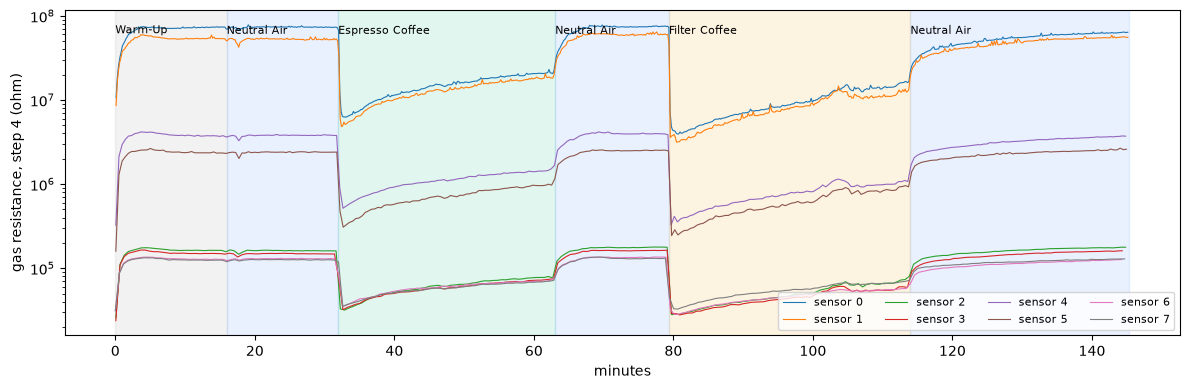

In [4]:
colors = {"Air": "#4c8dff", "Espresso": "#10b981", "Filter Coffee": "#f59e0b", None: "#999999"}
fig, ax = plt.subplots(figsize=(12, 4))
for s, g in df.groupby("sensor"):
    ax.plot(g["start"] / 60000, g["gas_3"], lw=0.8, label=f"sensor {s}")
for _, sp in r.specimens.iterrows():
    ax.axvspan(sp["start"] / 60000, sp["end"] / 60000, color=colors.get(sp["cls"], "#999"), alpha=0.12)
    ax.text(sp["start"] / 60000, df["gas_3"].max(), sp["name"], fontsize=8, va="top")
ax.set_yscale("log"); ax.set_xlabel("minutes"); ax.set_ylabel("gas resistance, step 4 (ohm)")
ax.legend(ncol=4, fontsize=8); plt.tight_layout()

### Fingerprints

For one heater profile, the median *shape* of each class across the ten heater steps (log resistance minus its mean, so the
overall level -- which drifts -- is removed). Where the lines differ, the sensor can tell the classes apart.

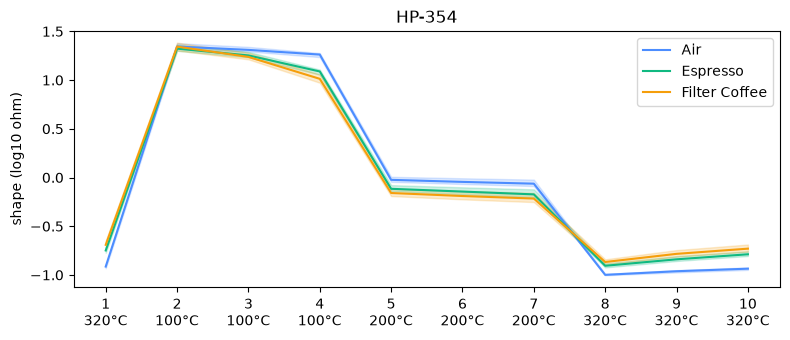

In [5]:
hp = df["heater_profile"].value_counts().idxmax()
d = df[(df["heater_profile"] == hp) & df["cls"].notna()]
shape = lab.features(d, "shape")[:, :10]
fig, ax = plt.subplots(figsize=(8, 3.5))
for c, idx in d.groupby("cls").indices.items():
    q = np.percentile(shape[idx], [25, 50, 75], axis=0)
    ax.plot(range(1, 11), q[1], label=c, color=colors[c]); ax.fill_between(range(1, 11), q[0], q[2], color=colors[c], alpha=0.2)
temps = [s[0] for s in r.heater_profile(hp)["steps"]]
ax.set_xticks(range(1, 11), [f"{i}\n{t}°C" for i, t in enumerate(temps, 1)])
ax.set_ylabel("shape (log10 ohm)"); ax.set_title(r.heater_profile(hp)["name"]); ax.legend(); plt.tight_layout()

## Check for confounding

If one class was recorded warmer or more humid than another, a model can learn the weather instead of the smell.

In [6]:
df[df["cls"].notna()].groupby("cls")[["temp", "hum"]].median().round(2)

,temp,hum
cls,,
Air,40.75,17.99
Espresso,42.33,16.36
Filter Coffee,42.52,16.24


In this demo the coffee was recorded about 1.7 °C warmer and slightly drier than the air (a hot coffee machine next to the sensors). Keeping
temperature and humidity *out* of the model's inputs (the default) and using the level-free `shape` features both help;
recording classes in alternating rounds helps most.

## Honest vs random testing

AI-Studio splits individual cycles at random: 70 % train, 30 % test. Neighbouring cycles of one specimen are nearly identical,
so the test set is full of near-copies of the training set. `split_by_specimen` keeps each specimen wholly on one side instead.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def score(s, tr, te):
    m = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(s.X[tr], s.y[tr])
    return accuracy_score(s.y[te], m.predict(s.X[te]))

rows = []
for task, classes in {
    "Air vs Coffee": {"Air": "Air", "Espresso": "Coffee", "Filter Coffee": "Coffee"},
    "Air vs Espresso vs Filter": {"Air": "Air", "Espresso": "Espresso", "Filter Coffee": "Filter Coffee"},
}.items():
    for feats in ["aistudio", "shape"]:
        s = lab.per_sensor(df, kind=feats, classes=classes)
        rows.append({"task": task, "features": feats,
                     "random split (AI-Studio way)": score(s, *lab.random_split(len(s))),
                     "honest (unseen specimens)": score(s, *lab.split_by_specimen(s)),
                     "warning": lab.split_warning(s) or ""})
pd.DataFrame(rows).round(3)

,task,features,random split (AI-Studio way),honest (unseen specimens),warning
0,Air vs Coffee,aistudio,0.993,0.979,
1,Air vs Coffee,shape,0.993,0.973,
2,Air vs Espresso vs Filter,aistudio,0.927,0.819,"Espresso, Filter Coffee have only one specimen..."
3,Air vs Espresso vs Filter,shape,0.975,0.877,"Espresso, Filter Coffee have only one specimen..."


Two things to read from this table:

* **The random split always looks better.** The gap is not skill, it's leakage between neighbouring cycles.
* **Espresso vs Filter Coffee has only one specimen of each** in this demo, so even the "honest" test has to split those
  specimens in time and is still optimistic (see the warning). The fix is data, not modelling: record each coffee several
  times, on different days.

### Group k-fold: every specimen tested once

With few specimens, one split is noisy. `group_kfold` tests every specimen exactly once, each by a model that never saw it.

In [8]:
s = lab.per_sensor(df, kind="shape", classes={"Air": "Air", "Espresso": "Coffee", "Filter Coffee": "Coffee"})
accs = [score(s, tr, te) for tr, te in lab.group_kfold(s, k=5)]
print("per fold:", np.round(accs, 3), " mean:", round(float(np.mean(accs)), 3))

per fold: [0.98  1.    0.966 0.995 1.   ]  mean: 0.988


### Across recordings

The toughest honest test is `leave_one_recording_out`: train on some sessions, test on a session recorded another time.
The demo has a single session, so it can't be run here -- with your own recordings from different days it is the test that
tells you whether a model will still work next week.

**Next:** `02_deep_models.ipynb` trains neural networks that read all eight sensors at once and follow the signal over time,
on the GPU; `03_self_supervised.ipynb` pre-trains on unlabelled data.